In [43]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/iris/Iris.csv
/kaggle/input/iris/database.sqlite


In [44]:
df = pd.read_csv('/kaggle/input/iris/Iris.csv')

In [45]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [46]:
df = df.iloc[:,1:]

In [47]:
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [48]:
from sklearn.preprocessing import LabelEncoder

In [49]:
encoder = LabelEncoder()

In [50]:
df['Species'] = encoder.fit_transform(df['Species'])

In [51]:
df.sample(5)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
7,5.0,3.4,1.5,0.2,0
105,7.6,3.0,6.6,2.1,2
35,5.0,3.2,1.2,0.2,0
132,6.4,2.8,5.6,2.2,2
120,6.9,3.2,5.7,2.3,2


In [52]:
df = df[df['Species'] != 0][['SepalWidthCm', 'PetalLengthCm', 'Species' ]]

In [53]:
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


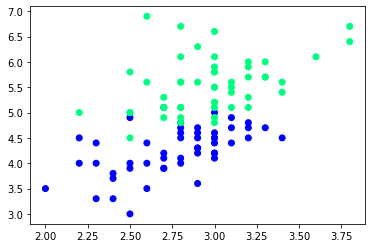

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.scatter(df['SepalWidthCm' ], df['PetalLengthCm' ], c=df[ 'Species' ], cmap='winter')

In [55]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80, : ].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [56]:
df_train

,SepalWidthCm,PetalLengthCm,Species
101,2.7,5.1,2
81,2.4,3.7,1
100,3.3,6.0,2
129,3.0,5.8,2
124,3.3,5.7,2
68,2.2,4.5,1
140,3.1,5.6,2
132,2.8,5.6,2
75,3.0,4.4,1
103,2.9,5.6,2


In [57]:
df_val

,SepalWidthCm,PetalLengthCm,Species
141,3.1,5.1,2
69,2.5,3.9,1
55,2.8,4.5,1
61,3.0,4.2,1
53,2.3,4.0,1


In [58]:
df_test

,SepalWidthCm,PetalLengthCm,Species
128,2.8,5.6,2
57,2.4,3.3,1
91,3.0,4.6,1
135,3.0,6.1,2
64,2.9,3.6,1


In [59]:
X_test = df_val.iloc[ :,0:2].values
y_test = df_val.iloc[ :,-1].values

In [60]:
X_test

array([[3.1, 5.1],
       [2.5, 3.9],
       [2.8, 4.5],
       [3. , 4.2],
       [2.3, 4. ]])

In [61]:
y_test

array([2, 1, 1, 1, 1])

## case-1 Bagging


In [62]:
# Data for Tree 1
df_bag = df_train.sample(8, replace=True)

X = df_bag.iloc[ :, 0:2]
y = df_bag. iloc[ :, -1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
103,2.9,5.6,2
100,3.3,6.0,2
124,3.3,5.7,2
132,2.8,5.6,2
132,2.8,5.6,2
75,3.0,4.4,1
101,2.7,5.1,2
129,3.0,5.8,2


In [63]:
from sklearn. tree import DecisionTreeClassifier
from sklearn. tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score


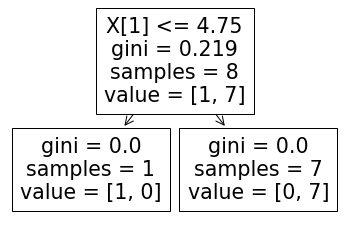

1.0


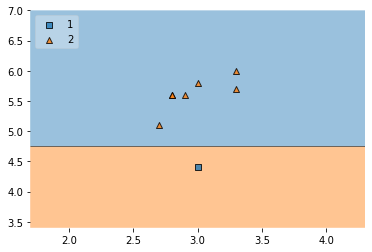

In [64]:
dt_bag1 = DecisionTreeClassifier()

evaluate(dt_bag1,X,y)

In [65]:
# Data for Tree 1
df_bag = df_train.sample(8, replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[ :,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
81,2.4,3.7,1
101,2.7,5.1,2
68,2.2,4.5,1
124,3.3,5.7,2
140,3.1,5.6,2
68,2.2,4.5,1
68,2.2,4.5,1
75,3.0,4.4,1


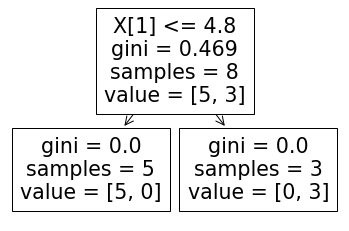

1.0


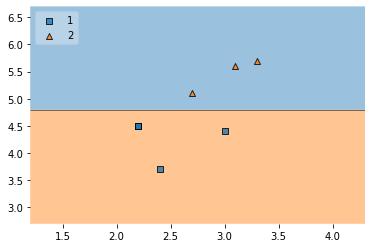

In [66]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [67]:
# Data for Tree 1
df_bag = df_train.sample(8, replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[ :,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
124,3.3,5.7,2
68,2.2,4.5,1
75,3.0,4.4,1
124,3.3,5.7,2
124,3.3,5.7,2
81,2.4,3.7,1
100,3.3,6.0,2
103,2.9,5.6,2


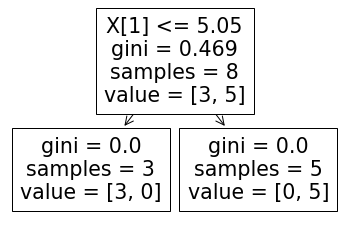

1.0


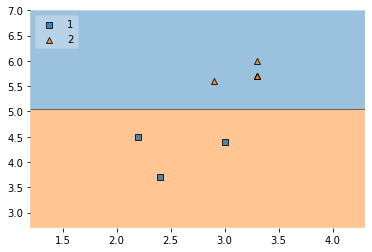

In [68]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

## predict

In [69]:
df_test

,SepalWidthCm,PetalLengthCm,Species
128,2.8,5.6,2
57,2.4,3.3,1
91,3.0,4.6,1
135,3.0,6.1,2
64,2.9,3.6,1


In [70]:
print("Predictor 1",dt_bag1.predict(np.array([2.8,5.6]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.8,5.6]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.8,5.6]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 3 [2]


In [28]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test, y_pred))

## pasting

In [72]:
# Row sampling without replacement
df_train

,SepalWidthCm,PetalLengthCm,Species
101,2.7,5.1,2
81,2.4,3.7,1
100,3.3,6.0,2
129,3.0,5.8,2
124,3.3,5.7,2
68,2.2,4.5,1
140,3.1,5.6,2
132,2.8,5.6,2
75,3.0,4.4,1
103,2.9,5.6,2


In [73]:
df_train.sample(8)

,SepalWidthCm,PetalLengthCm,Species
68,2.2,4.5,1
132,2.8,5.6,2
124,3.3,5.7,2
129,3.0,5.8,2
140,3.1,5.6,2
100,3.3,6.0,2
75,3.0,4.4,1
101,2.7,5.1,2


In [74]:
## Random sequence

In [76]:
df1 = pd.read_csv('/kaggle/input/iris/Iris.csv')
df1 = df1.sample(10)

In [77]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
121,122,5.6,2.8,4.9,2.0,Iris-virginica
109,110,7.2,3.6,6.1,2.5,Iris-virginica
45,46,4.8,3.0,1.4,0.3,Iris-setosa
51,52,6.4,3.2,4.5,1.5,Iris-versicolor
83,84,6.0,2.7,5.1,1.6,Iris-versicolor
145,146,6.7,3.0,5.2,2.3,Iris-virginica
102,103,7.1,3.0,5.9,2.1,Iris-virginica
84,85,5.4,3.0,4.5,1.5,Iris-versicolor
74,75,6.4,2.9,4.3,1.3,Iris-versicolor
123,124,6.3,2.7,4.9,1.8,Iris-virginica


In [78]:
df1.sample(2, replace=True, axis=1)

,PetalLengthCm,Id
121,4.9,122
109,6.1,110
45,1.4,46
51,4.5,52
83,5.1,84
145,5.2,146
102,5.9,103
84,4.5,85
74,4.3,75
123,4.9,124


### random patches

In [79]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
121,122,5.6,2.8,4.9,2.0,Iris-virginica
109,110,7.2,3.6,6.1,2.5,Iris-virginica
45,46,4.8,3.0,1.4,0.3,Iris-setosa
51,52,6.4,3.2,4.5,1.5,Iris-versicolor
83,84,6.0,2.7,5.1,1.6,Iris-versicolor
145,146,6.7,3.0,5.2,2.3,Iris-virginica
102,103,7.1,3.0,5.9,2.1,Iris-virginica
84,85,5.4,3.0,4.5,1.5,Iris-versicolor
74,75,6.4,2.9,4.3,1.3,Iris-versicolor
123,124,6.3,2.7,4.9,1.8,Iris-virginica


In [80]:
df1.sample(8,replace=True).sample(2,replace=True, axis=1)

,SepalWidthCm,Species
102,3.0,Iris-virginica
121,2.8,Iris-virginica
45,3.0,Iris-setosa
121,2.8,Iris-virginica
51,3.2,Iris-versicolor
74,2.9,Iris-versicolor
84,3.0,Iris-versicolor
74,2.9,Iris-versicolor
